# Acreción utilizando las correcciones del código de Claude
### Ahora aparece un factor de eficiencia en la acreción $\lambda$ y desaparece el factor de acreción 

In [1]:
import sys, os
# Robustez de import (P2-14/ronda 2): anade la raiz del repo y PBHBeta/ a sys.path para
# que funcione tanto si el notebook se ejecuta desde pbh-beta/ como desde PBHBeta/.
_here = os.getcwd()
for _p in (_here, os.path.dirname(_here)):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from PBHBeta import constants
import functionscorr as fn_comp
import jax
import jax.numpy as jnp
from scipy.optimize import brentq
import equinox as eqx
import jax.lax as lax
from diffrax import diffeqsolve, ODETerm, Tsit5, PIDController, SaveAt

# Ronda 2 (ver PROMPT_VSCODE_V2.md / DERIVACION_ACRECION.md): el modelo default de
# fn_comp.precalcular_acreccion_lote ahora es regime='wave' (Unruh 1976), con
# L_ACC_DEFAULT = 16*pi y GAMMA_COLAPSO = 0.15 (no gamma_reh=1: L*gamma < 4*pi es
# condicion de existencia de la solucion, ver fn_comp.assert_subcritical). El argumento
# `lam=` de la ronda 1 se llama ahora `L_acc=`. El modelo de la ronda 1
# (min(Michel,cap), horizon-tracking) se conserva en regime='horizon_tracking'.
print("L_ACC_DEFAULT (wave) =", fn_comp.L_ACC_DEFAULT)
print("GAMMA_COLAPSO =", fn_comp.GAMMA_COLAPSO)
print("mu teorico = 1/(1-L*gamma/4pi) =",
      1.0/(1.0 - fn_comp.L_ACC_DEFAULT*fn_comp.GAMMA_COLAPSO/(4*np.pi)))


L_ACC_DEFAULT (wave) = 50.26548245743669
GAMMA_COLAPSO = 0.15
mu teorico = 1/(1-L*gamma/4pi) = 2.5


In [2]:

def calcular_envolvente_sbb(M_tot, omega_sbb):
    """Calcula y devuelve la envolvente de todas las restricciones SBB base."""
    limpiar_memoria()
    fn_comp.Betas_DM(M_tot, omega_sbb)
    fn_comp.Betas_BBN(M_tot, omega_sbb)
    fn_comp.Betas_SD(M_tot, omega_sbb)
    fn_comp.Betas_CMB_AN(M_tot, omega_sbb)
    fn_comp.Betas_GRB(M_tot, omega_sbb)
    fn_comp.Betas_Reio(M_tot, omega_sbb)
    fn_comp.Betas_LSP(M_tot, omega_sbb)
    return fn_comp.get_Betas_full(M_tot)

def formato_grafica(titulo):
    """Aplica formato estándar a las gráficas."""
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(r'$M_i$ [g]', fontsize=13)
    plt.ylabel(r'$\beta$', fontsize=13)
    #plt.title(titulo, fontsize=14)
    plt.xlim(1.0, 1e20)
    plt.ylim(1e-35, 1e0)
    plt.legend(fontsize=10, loc='upper right', ncol=2)
    plt.grid(False, which="both", ls=":", alpha=0.5)
    plt.tight_layout()

1. Evaluando restriccion exclusiva de Materia Oscura (DM)...


Calculando dinamica para L = 25.00...


Calculando dinamica para L = 40.00...


Calculando dinamica para L = 50.27...


/var/folders/_k/mvlldjgn0tg8rvrhm06zy71w0000gn/T/ipykernel_74172/2438531416.py:23: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  plt.grid(False, which="both", ls=":", alpha=0.5)


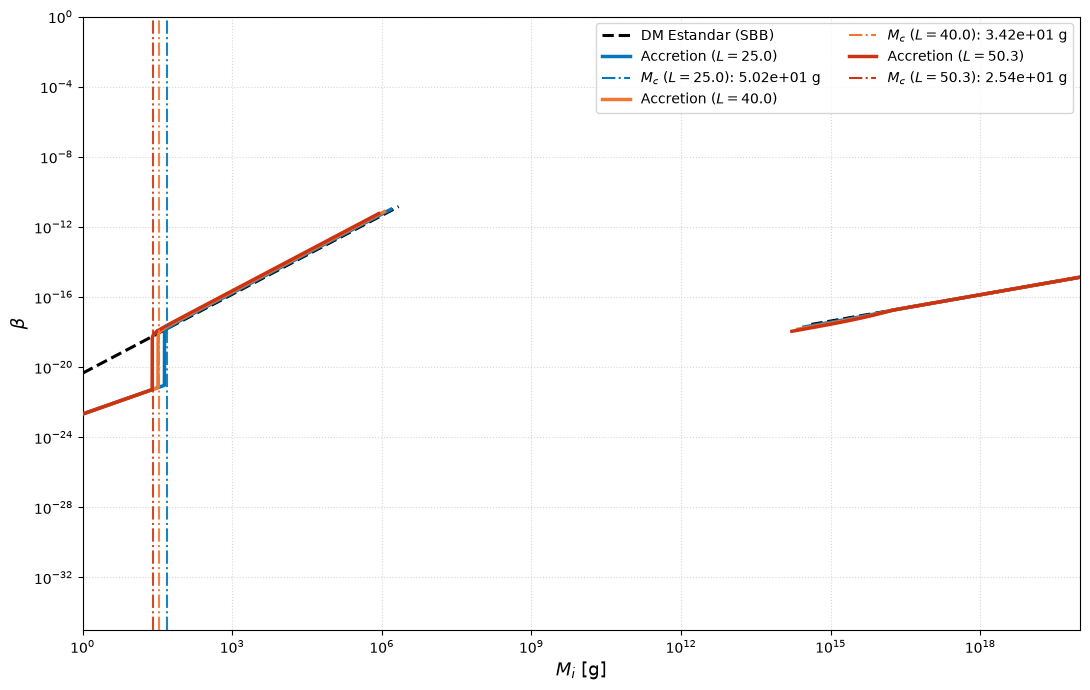

In [3]:
def limpiar_memoria():
    """Limpia las variables globales de PBHBeta para aislar las evaluaciones."""
    fn_comp.constraints.betas_DM_tot = []
    fn_comp.constraints.betas_LSP_tot = []
    fn_comp.constraints.betas_BBN_tot = []
    fn_comp.constraints.betas_SD_tot = []
    fn_comp.constraints.betas_CMB_AN_tot = []
    fn_comp.constraints.betas_GRB_tot = []
    fn_comp.constraints.betas_Reio_tot = []

def encontrar_masa_critica_num(N_fin, a_star, L_acc):
    """Encuentra la masa exacta de transicion (mu=1) usando el integrador JAX principal."""
    def balance_neto(log_Mi):
        Mi_g = 10.0**log_Mi
        Mi_jnp = jnp.array([Mi_g], dtype=jnp.float64)
        M_f_tot_jnp, _ = fn_comp.precalcular_acreccion_lote(Mi_jnp, N_fin, a_star, L_acc=L_acc)
        Mf_g = float(M_f_tot_jnp[0])
        return float(np.log10(Mf_g / Mi_g))

    try:
        log_Mc = brentq(balance_neto, -2.0, 10.0, xtol=1e-4)
        return 10.0**log_Mc
    except ValueError as e:
        print(f"Advertencia: No se encontro masa critica para L={L_acc}. Error: {e}")
        return None

def graficar_solo_DM():
    print("1. Evaluando restriccion exclusiva de Materia Oscura (DM)...")
    M_tot = fn_comp.put_M_array(1e-5, 1e22, num_points_low=10000)
    M_tot_jnp = jnp.array(M_tot, dtype=jnp.float64)

    omega_sbb = 1.0 / 3.0
    N_fin = 25.0
    a_star = 0.0

    limpiar_memoria()
    fn_comp.Betas_DM(M_tot, omega_sbb)
    beta_dm_sbb = np.array(fn_comp.constraints.betas_DM_tot)

    plt.figure(figsize=(11, 7))
    b_sbb_plot = np.where(beta_dm_sbb == fn_comp.constants.ev1, np.nan, beta_dm_sbb)
    plt.plot(M_tot, b_sbb_plot, 'k--', lw=2.2, label='DM Estandar (SBB)', zorder=2)

    # Barrido en L (ronda 2): valores alrededor de L_ACC_DEFAULT=16*pi, todos
    # subcriticos con GAMMA_COLAPSO=0.15 (L*gamma<4*pi=12.566 <=> L<83.8).
    L_list = [25.0, 40.0, fn_comp.L_ACC_DEFAULT]
    colores = ['#0077BB', '#EE7733', '#CC3311']

    for idx, L_acc in enumerate(L_list):
        print(f"Calculando dinamica para L = {L_acc:.2f}...")
        Mc = encontrar_masa_critica_num(N_fin, a_star, L_acc)
        M_f_tot_jnp, _ = fn_comp.precalcular_acreccion_lote(M_tot_jnp, N_fin, a_star, L_acc=L_acc)
        beta_acc = fn_comp.aplicar_corrimiento_acrecion(M_tot, np.array(M_f_tot_jnp), beta_dm_sbb)

        b_plot = np.where(beta_acc == fn_comp.constants.ev1, np.nan, beta_acc)
        plt.plot(M_tot, b_plot, color=colores[idx], lw=2.5, label=rf'Accretion ($L={L_acc:.1f}$)', zorder=3)

        if Mc:
            plt.axvline(x=Mc, color=colores[idx], linestyle='-.', lw=1.5, alpha=0.9, zorder=4)
            plt.plot([], [], color=colores[idx], linestyle='-.', label=rf'$M_c$ ($L={L_acc:.1f}$): {Mc:.2e} g')

    formato_grafica(rf'Cota de Materia Oscura (DM) con acrecion ($N_{{fin}}={N_fin}, a_*={a_star}$)')
    plt.savefig('dmonly.pdf')
    plt.show()

if __name__ == "__main__":
    graficar_solo_DM()


2. Verificando planitud en N_re y graficando envolvente completa...


   verificacion planitud: mu(N_fin) = ['2.4993', '2.4994', '2.4997', '2.5003']  (spread relativo = 4.15e-04)
   -> Integrando N_fin = 15.0...


   -> Integrando N_fin = 20.0...


   -> Integrando N_fin = 25.0...


   -> Integrando N_fin = 30.0...


/var/folders/_k/mvlldjgn0tg8rvrhm06zy71w0000gn/T/ipykernel_74172/2438531416.py:23: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  plt.grid(False, which="both", ls=":", alpha=0.5)


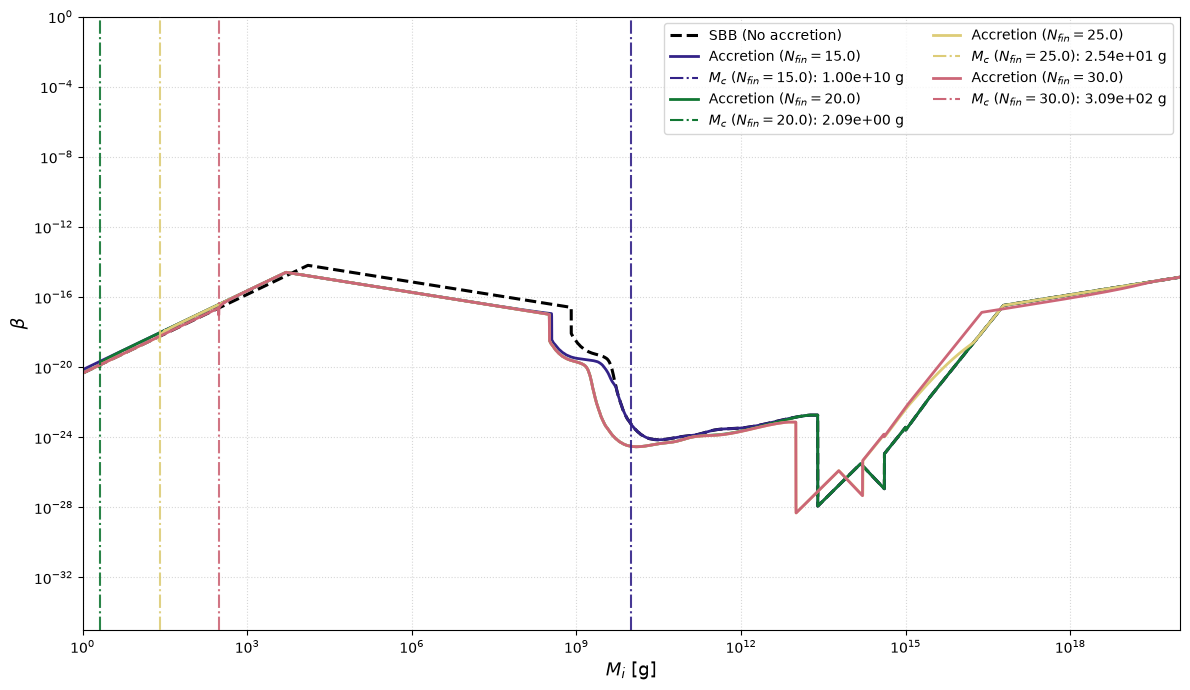

In [4]:
def limpiar_memoria():
    """Limpia las variables globales de PBHBeta para aislar las evaluaciones."""
    fn_comp.constraints.betas_DM_tot = []
    fn_comp.constraints.betas_LSP_tot = []
    fn_comp.constraints.betas_BBN_tot = []
    fn_comp.constraints.betas_SD_tot = []
    fn_comp.constraints.betas_CMB_AN_tot = []
    fn_comp.constraints.betas_GRB_tot = []
    fn_comp.constraints.betas_Reio_tot = []
# ====================================================================
# 2. BARRIDO EN E-FOLDS (N_fin) -- ronda 2: bajo regime='wave' esto DEBE
# salir plano (mu no depende de N_re, DERIVACION_ACRECION.md S3 -- la
# integral satura en pocos e-folds). Si no sale plano hay un bug: este
# barrido paso de ser "un resultado" a ser un test, con verificacion
# numerica explicita antes de graficar.
# ====================================================================
def encontrar_masa_critica_num(N_fin, a_star, L_acc):
    def balance_neto(log_Mi):
        Mi_g = 10.0**log_Mi
        Mi_jnp = jnp.array([Mi_g], dtype=jnp.float64)
        M_f_tot_jnp, _ = fn_comp.precalcular_acreccion_lote(Mi_jnp, N_fin, a_star, L_acc=L_acc)
        Mf_g = float(M_f_tot_jnp[0])
        return float(np.log10(Mf_g / Mi_g))
    try:
        log_Mc = brentq(balance_neto, -2.0, 10.0, xtol=1e-4)
        return 10.0**log_Mc
    except ValueError as e:
        print(f"Advertencia: No se encontro masa critica para eFolds={N_fin}. Error: {e}")
        return None

def verificar_planitud_Nre(L_acc, a_star, M_test_g=1e4, N_list=(15.0, 20.0, 25.0, 30.0)):
    """Chequeo (ronda 2, Tarea 6): mu(M_test_g) debe ser el mismo para todo N_fin en
    N_list -- si no, algo del modelo horizon-tracking (ronda 1) se colo por error."""
    Mi = jnp.array([M_test_g], dtype=jnp.float64)
    mus = []
    for N_fin in N_list:
        _, mu = fn_comp.precalcular_acreccion_lote(Mi, N_fin, a_star, L_acc=L_acc)
        mus.append(float(mu[0]))
    spread = (max(mus) - min(mus)) / np.mean(mus)
    print(f"   verificacion planitud: mu(N_fin) = {[f'{m:.4f}' for m in mus]}  "
          f"(spread relativo = {spread:.2e})")
    assert spread < 1e-2, (
        f"mu NO es plano en N_re (spread={spread:.2e}) -- regime='wave' deberia dar "
        f"mu independiente de N_re para M_i muy por encima de M_crit. Revisar antes de "
        f"confiar en esta figura."
    )
    return mus

def graficar_efolds():
    print("2. Verificando planitud en N_re y graficando envolvente completa...")
    M_tot = fn_comp.put_M_array(1.0, 1e22)
    M_tot_jnp = jnp.array(M_tot, dtype=jnp.float64)
    omega_sbb = 1.0 / 3.0

    betas_sbb_full = calcular_envolvente_sbb(M_tot, omega_sbb)
    b_sbb_plot = np.where(betas_sbb_full == fn_comp.constants.ev1, np.nan, betas_sbb_full)

    plt.figure(figsize=(12, 7))
    plt.plot(M_tot, b_sbb_plot, 'k--', lw=2.2, label='SBB (No accretion)')

    L_acc = fn_comp.L_ACC_DEFAULT
    a_star = 0.0
    N_list = [15.0, 20.0, 25.0, 30.0]
    colores = ['#332288', '#117733', '#DDCC77', '#CC6677']

    verificar_planitud_Nre(L_acc, a_star, N_list=tuple(N_list))

    for idx, N_fin in enumerate(N_list):
        print(f"   -> Integrando N_fin = {N_fin}...")
        Mc = encontrar_masa_critica_num(N_fin, a_star, L_acc)
        M_f_tot_jnp, _ = fn_comp.precalcular_acreccion_lote(M_tot_jnp, N_fin, a_star, L_acc=L_acc)
        beta_acc = fn_comp.aplicar_corrimiento_acrecion(M_tot, np.array(M_f_tot_jnp), betas_sbb_full)

        b_plot = np.where(beta_acc == fn_comp.constants.ev1, np.nan, beta_acc)
        plt.plot(M_tot, b_plot, color=colores[idx], lw=2, label=rf'Accretion ($N_{{fin}}={N_fin}$)')

        if Mc:
            plt.axvline(x=Mc, color=colores[idx], linestyle='-.', lw=1.5, alpha=0.9, zorder=4)
            plt.plot([], [], color=colores[idx], linestyle='-.', label=rf'$M_c$ ($N_{{fin}}={N_fin}$): {Mc:.2e} g')

    formato_grafica(rf'Restricciones variando N_re ($L={L_acc:.1f}$) -- las curvas de '
                     rf'acrecion deberian solaparse casi del todo (mu no depende de N_re)')
    plt.savefig('efoldsarray.pdf')
    plt.show()

if __name__ == "__main__":
    graficar_efolds()


3. Evaluando constraints completas barriendo el Espin (a_*)...


   -> Integrando a_* = 0.0...


   -> Integrando a_* = 0.7...


   -> Integrando a_* = 0.9...


   -> Integrando a_* = 0.99...


/var/folders/_k/mvlldjgn0tg8rvrhm06zy71w0000gn/T/ipykernel_74172/2438531416.py:23: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  plt.grid(False, which="both", ls=":", alpha=0.5)


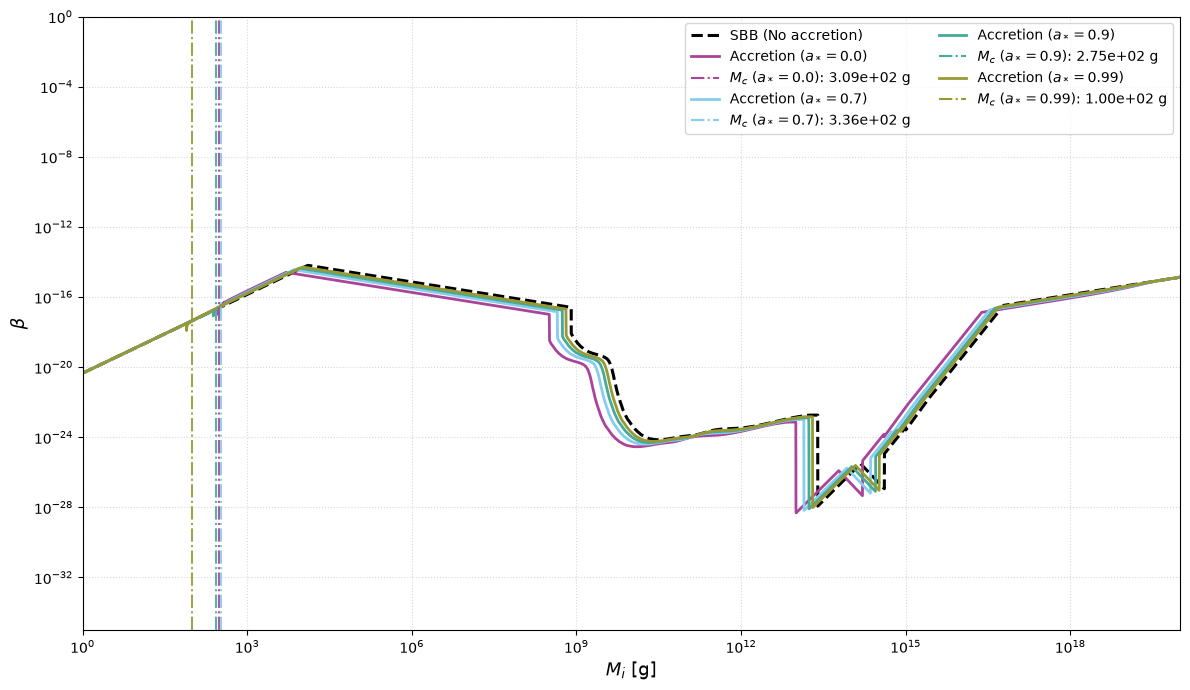

In [5]:
def limpiar_memoria():
    """Limpia las variables globales de PBHBeta para aislar las evaluaciones."""
    fn_comp.constraints.betas_DM_tot = []
    fn_comp.constraints.betas_LSP_tot = []
    fn_comp.constraints.betas_BBN_tot = []
    fn_comp.constraints.betas_SD_tot = []
    fn_comp.constraints.betas_CMB_AN_tot = []
    fn_comp.constraints.betas_GRB_tot = []
    fn_comp.constraints.betas_Reio_tot = []
# ====================================================================
# 3. BARRIDO EN ESPIN (a_star) -- ronda 2: este SI tiene contenido fisico
# bajo regime='wave' (f_espin baja L_eff y por tanto mu -- ver
# DERIVACION_ACRECION.md, factor_espin_acc en L_eff).
# ====================================================================
def encontrar_masa_critica_num(N_fin, a_star, L_acc):
    def balance_neto(log_Mi):
        Mi_g = 10.0**log_Mi
        Mi_jnp = jnp.array([Mi_g], dtype=jnp.float64)
        M_f_tot_jnp, _ = fn_comp.precalcular_acreccion_lote(Mi_jnp, N_fin, a_star, L_acc=L_acc)
        Mf_g = float(M_f_tot_jnp[0])
        return float(np.log10(Mf_g / Mi_g))
    try:
        log_Mc = brentq(balance_neto, -2.0, 10.0, xtol=1e-4)
        return 10.0**log_Mc
    except ValueError as e:
        print(f"Advertencia: No se encontro masa critica para Spin={a_star}. Error: {e}")
        return None

def graficar_espin():
    print("3. Evaluando constraints completas barriendo el Espin (a_*)...")
    M_tot = fn_comp.put_M_array(1.0, 1e22)
    M_tot_jnp = jnp.array(M_tot, dtype=jnp.float64)
    omega_sbb = 1.0 / 3.0

    betas_sbb_full = calcular_envolvente_sbb(M_tot, omega_sbb)
    b_sbb_plot = np.where(betas_sbb_full == fn_comp.constants.ev1, np.nan, betas_sbb_full)

    plt.figure(figsize=(12, 7))
    plt.plot(M_tot, b_sbb_plot, 'k--', lw=2.2, label='SBB (No accretion)')

    L_acc = fn_comp.L_ACC_DEFAULT
    N_fin = 30.0
    a_list = [0.0, 0.7, 0.9, 0.99]
    colores = ['#AA4499', '#88CCEE', '#44AA99', '#999933']

    for idx, a_star in enumerate(a_list):
        print(f"   -> Integrando a_* = {a_star}...")
        Mc = encontrar_masa_critica_num(N_fin, a_star, L_acc)
        M_f_tot_jnp, _ = fn_comp.precalcular_acreccion_lote(M_tot_jnp, N_fin, a_star, L_acc=L_acc)
        beta_acc = fn_comp.aplicar_corrimiento_acrecion(M_tot, np.array(M_f_tot_jnp), betas_sbb_full)

        b_plot = np.where(beta_acc == fn_comp.constants.ev1, np.nan, beta_acc)
        plt.plot(M_tot, b_plot, color=colores[idx], lw=2, label=rf'Accretion ($a_*={a_star}$)')
        if Mc:
            plt.axvline(x=Mc, color=colores[idx], linestyle='-.', lw=1.5, alpha=0.9, zorder=4)
            plt.plot([], [], color=colores[idx], linestyle='-.', label=rf'$M_c$ ($a_*={a_star}$): {Mc:.2e} g')

    formato_grafica(rf'Transicion de regimen segun espin inicial ($L={L_acc:.1f}, N_{{fin}}={N_fin}$)')
    plt.savefig('spinarray.pdf')
    plt.show()
if __name__ == "__main__":
    graficar_espin()


4. Evaluando constraints completas barriendo L...


   -> Integrando L = 20.00...


   -> Integrando L = 35.00...


   -> Integrando L = 50.27...


   -> Integrando L = 65.00...


/var/folders/_k/mvlldjgn0tg8rvrhm06zy71w0000gn/T/ipykernel_74172/2438531416.py:23: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  plt.grid(False, which="both", ls=":", alpha=0.5)


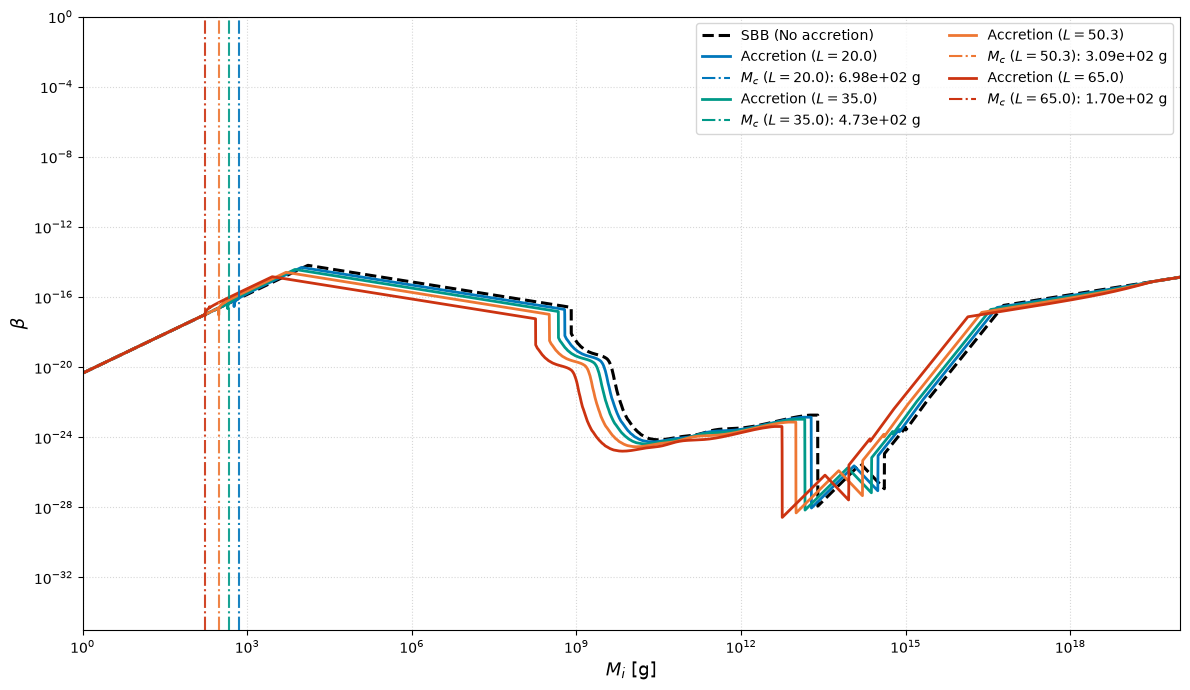

In [6]:
def limpiar_memoria():
    """Limpia las variables globales de PBHBeta para aislar las evaluaciones."""
    fn_comp.constraints.betas_DM_tot = []
    fn_comp.constraints.betas_LSP_tot = []
    fn_comp.constraints.betas_BBN_tot = []
    fn_comp.constraints.betas_SD_tot = []
    fn_comp.constraints.betas_CMB_AN_tot = []
    fn_comp.constraints.betas_GRB_tot = []
    fn_comp.constraints.betas_Reio_tot = []
# ====================================================================
# 4. BARRIDO EN L (eficiencia de acrecion, Unruh) -- ronda 2: valores
# alrededor de L_ACC_DEFAULT=16*pi, respetando L*gamma<4*pi=12.566 con
# GAMMA_COLAPSO=0.15 (L<83.8).
# ====================================================================
def encontrar_masa_critica_num(N_fin, a_star, L_acc):
    def balance_neto(log_Mi):
        Mi_g = 10.0**log_Mi
        Mi_jnp = jnp.array([Mi_g], dtype=jnp.float64)
        M_f_tot_jnp, _ = fn_comp.precalcular_acreccion_lote(Mi_jnp, N_fin, a_star, L_acc=L_acc)
        Mf_g = float(M_f_tot_jnp[0])
        return float(np.log10(Mf_g / Mi_g))
    try:
        log_Mc = brentq(balance_neto, -2.0, 10.0, xtol=1e-4)
        return 10.0**log_Mc
    except ValueError as e:
        print(f"Advertencia: No se encontro masa critica para L={L_acc}. Error: {e}")
        return None

def graficar_lambda():
    print("4. Evaluando constraints completas barriendo L...")
    M_tot = fn_comp.put_M_array(1.0, 1e22)
    M_tot_jnp = jnp.array(M_tot, dtype=jnp.float64)
    omega_sbb = 1.0 / 3.0

    betas_sbb_full = calcular_envolvente_sbb(M_tot, omega_sbb)
    b_sbb_plot = np.where(betas_sbb_full == fn_comp.constants.ev1, np.nan, betas_sbb_full)

    plt.figure(figsize=(12, 7))
    plt.plot(M_tot, b_sbb_plot, 'k--', lw=2.2, label='SBB (No accretion)')

    N_fin = 30.0
    a_star = 0.0
    L_list = [20.0, 35.0, fn_comp.L_ACC_DEFAULT, 65.0]
    colores = ['#0077BB', '#009988', '#EE7733', '#CC3311']

    for idx, L_acc in enumerate(L_list):
        print(f"   -> Integrando L = {L_acc:.2f}...")
        Mc = encontrar_masa_critica_num(N_fin, a_star, L_acc)
        M_f_tot_jnp, _ = fn_comp.precalcular_acreccion_lote(M_tot_jnp, N_fin, a_star, L_acc=L_acc)
        beta_acc = fn_comp.aplicar_corrimiento_acrecion(M_tot, np.array(M_f_tot_jnp), betas_sbb_full)

        b_plot = np.where(beta_acc == fn_comp.constants.ev1, np.nan, beta_acc)
        plt.plot(M_tot, b_plot, color=colores[idx], lw=2, label=rf'Accretion ($L={L_acc:.1f}$)')
        if Mc:
            plt.axvline(x=Mc, color=colores[idx], linestyle='-.', lw=1.5, alpha=0.9, zorder=4)
            plt.plot([], [], color=colores[idx], linestyle='-.', label=rf'$M_c$ ($L={L_acc:.1f}$): {Mc:.2e} g')

    formato_grafica(rf'Desplazamiento segun eficiencia L ($N_{{fin}}={N_fin}, a_*={a_star}$)')
    plt.savefig('lamarray.pdf')
    plt.show()

if __name__ == "__main__":
    graficar_lambda()


4bis. Evaluando constraints completas barriendo L (a_*=0.9)...


   -> Integrando L = 20.00...


   -> Integrando L = 35.00...


   -> Integrando L = 50.27...


   -> Integrando L = 65.00...


   -> Integrando L = 80.00...


/var/folders/_k/mvlldjgn0tg8rvrhm06zy71w0000gn/T/ipykernel_74172/2438531416.py:23: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  plt.grid(False, which="both", ls=":", alpha=0.5)


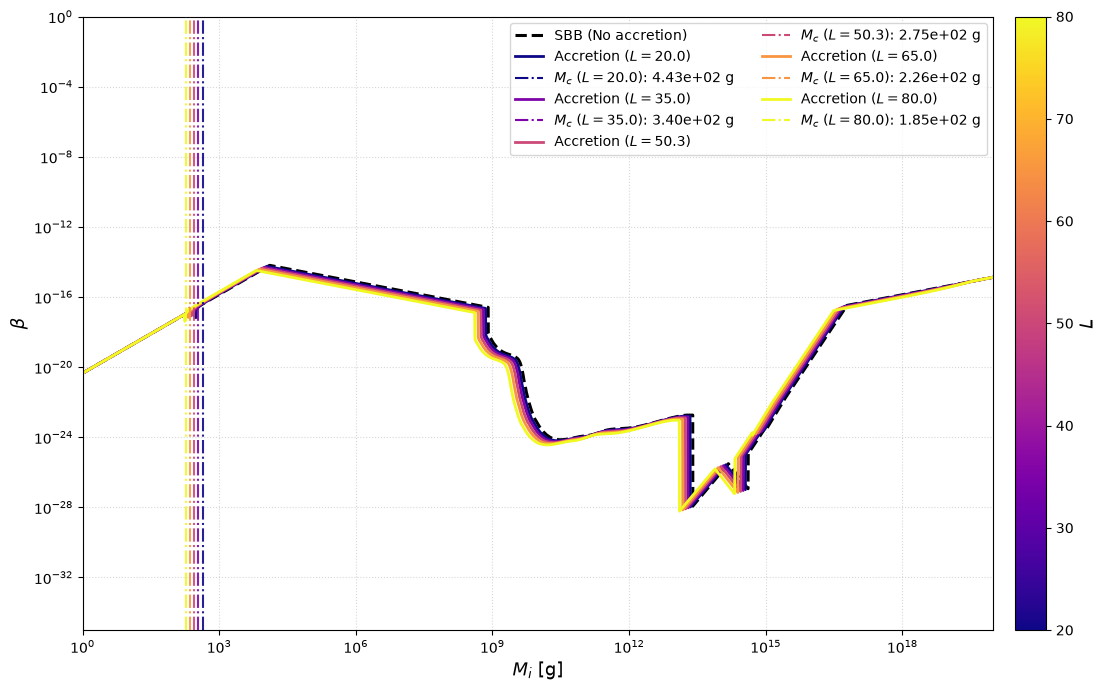

In [7]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

def limpiar_memoria():
    """Limpia las variables globales de PBHBeta para aislar las evaluaciones."""
    fn_comp.constraints.betas_DM_tot = []
    fn_comp.constraints.betas_LSP_tot = []
    fn_comp.constraints.betas_BBN_tot = []
    fn_comp.constraints.betas_SD_tot = []
    fn_comp.constraints.betas_CMB_AN_tot = []
    fn_comp.constraints.betas_GRB_tot = []
    fn_comp.constraints.betas_Reio_tot = []

def encontrar_masa_critica_num(N_fin, a_star, L_acc):
    def balance_neto(log_Mi):
        Mi_g = 10.0**log_Mi
        Mi_jnp = jnp.array([Mi_g], dtype=jnp.float64)
        M_f_tot_jnp, _ = fn_comp.precalcular_acreccion_lote(Mi_jnp, N_fin, a_star, L_acc=L_acc)
        Mf_g = float(M_f_tot_jnp[0])
        return float(np.log10(Mf_g / Mi_g))
    try:
        log_Mc = brentq(balance_neto, -2.0, 10.0, xtol=1e-4)
        return 10.0**log_Mc
    except ValueError as e:
        print(f"Advertencia: No se encontro masa critica para L={L_acc}. Error: {e}")
        return None

# ====================================================================
# 4bis. BARRIDO EN L CON COLORBAR, a_*=0.9 (ronda 2: el espin alto da
# mas margen -- factor_espin_acc(0.9)~0.515 reduce L_eff, asi que el
# limite admisible de L sube a ~4*pi/(gamma*factor_espin_acc)~163)
# ====================================================================

def graficar_lambda():
    print("4bis. Evaluando constraints completas barriendo L (a_*=0.9)...")

    M_tot = fn_comp.put_M_array(1.0, 1e22)
    M_tot_jnp = jnp.array(M_tot, dtype=jnp.float64)
    omega_sbb = 1.0 / 3.0

    betas_sbb_full = calcular_envolvente_sbb(M_tot, omega_sbb)
    b_sbb_plot = np.where(betas_sbb_full == fn_comp.constants.ev1, np.nan, betas_sbb_full)

    fig, ax = plt.subplots(figsize=(12, 7))
    ax.plot(M_tot, b_sbb_plot, 'k--', lw=2.2, label='SBB (No accretion)')

    N_fin = 30.0
    a_star = 0.9

    L_list = [20.0, 35.0, fn_comp.L_ACC_DEFAULT, 65.0, 80.0]

    cmap = plt.get_cmap('plasma')
    norm = mcolors.Normalize(vmin=min(L_list), vmax=max(L_list))

    for L_acc in L_list:
        print(f"   -> Integrando L = {L_acc:.2f}...")
        color_L = cmap(norm(L_acc))

        Mc = encontrar_masa_critica_num(N_fin, a_star, L_acc)
        M_f_tot_jnp, _ = fn_comp.precalcular_acreccion_lote(M_tot_jnp, N_fin, a_star, L_acc=L_acc)
        beta_acc = fn_comp.aplicar_corrimiento_acrecion(M_tot, np.array(M_f_tot_jnp), betas_sbb_full)

        b_plot = np.where(beta_acc == fn_comp.constants.ev1, np.nan, beta_acc)
        ax.plot(M_tot, b_plot, color=color_L, lw=2, label=rf'Accretion ($L={L_acc:.1f}$)')

        if Mc:
            ax.axvline(x=Mc, color=color_L, linestyle='-.', lw=1.5, alpha=0.9, zorder=4)
            ax.plot([], [], color=color_L, linestyle='-.', label=rf'$M_c$ ($L={L_acc:.1f}$): {Mc:.2e} g')

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label(r'$L$', fontsize=13)

    formato_grafica(rf'Desplazamiento segun eficiencia L ($N_{{fin}}={N_fin}, a_*={a_star}$)')
    plt.savefig('lamarray_colorbar.pdf')
    plt.show()

if __name__ == "__main__":
    graficar_lambda()


1/4 - Generando espacio de masas...
2/4 - Evaluando modelo Estandar (SBB)...


3/4 - JAX: Calculando dinamica de acrecion y aplicando shift...


4/4 - Procesando grafica comparativa...


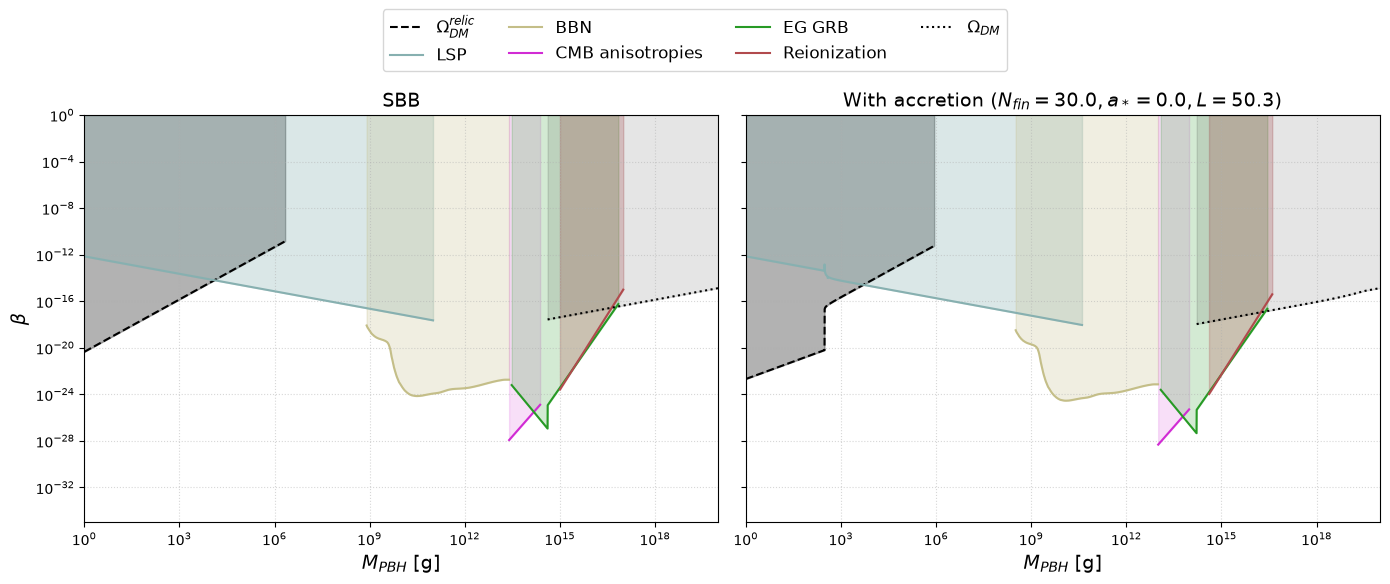

In [8]:
def limpiar_memoria():
    """Limpia las variables globales de PBHBeta para evitar que los modelos se mezclen."""
    fn_comp.constraints.betas_DM_tot = []
    fn_comp.constraints.betas_BBN_tot = []
    fn_comp.constraints.betas_SD_tot = []
    fn_comp.constraints.betas_CMB_AN_tot = []
    fn_comp.constraints.betas_GRB_tot = []
    fn_comp.constraints.betas_Reio_tot = []
    fn_comp.constraints.betas_LSP_tot = []

def clean_beta(b):
    """Enmascara los valores invalidos (ev1 o NaN) para que matplotlib no trace caidas
    falsas. Desde P0-3 (ronda 1), aplicar_corrimiento_acrecion devuelve np.nan (no
    ev1) para puntos no calculables -- np.where ya deja pasar el NaN existente."""
    return np.where(b == constants.ev1, np.nan, b)

def graficar_comparativa_espectros():
    print("1/4 - Generando espacio de masas...")
    M_tot = fn_comp.put_M_array(1e-5, 1e22)
    M_tot_jnp = jnp.array(M_tot, dtype=jnp.float64)

    omega = 1.0/3.0  # Las restricciones estandar SBB se mapean en radiacion
    N_fin = 30.00
    a_star = 0.0
    L_acc = fn_comp.L_ACC_DEFAULT  # Unruh 1976, ronda 2 (antes: lam=1.8, modelo viejo)

    # ---------------------------------------------------------
    # 1. CALCULO DEL MODELO ESTANDAR (SBB)
    # ---------------------------------------------------------
    print("2/4 - Evaluando modelo Estandar (SBB)...")
    limpiar_memoria()

    fn_comp.Betas_DM(M_tot, omega)
    fn_comp.Betas_LSP(M_tot, omega)
    fn_comp.Betas_BBN(M_tot, omega)
    fn_comp.Betas_CMB_AN(M_tot, omega)
    fn_comp.Betas_GRB(M_tot, omega)
    fn_comp.Betas_Reio(M_tot, omega)

    b_dm_std = np.array(fn_comp.constraints.betas_DM_tot)
    b_lsp_std = np.array(fn_comp.constraints.betas_LSP_tot)
    b_bbn_std = np.array(fn_comp.constraints.betas_BBN_tot)
    b_cmb_std = np.array(fn_comp.constraints.betas_CMB_AN_tot)
    b_grb_std = np.array(fn_comp.constraints.betas_GRB_tot)
    b_reio_std = np.array(fn_comp.constraints.betas_Reio_tot)

    # ---------------------------------------------------------
    # 2. CALCULO CON ACRECION (JAX, regime='wave') Y CORRIMIENTO EXACTO
    # ---------------------------------------------------------
    print("3/4 - JAX: Calculando dinamica de acrecion y aplicando shift...")
    M_f_tot_jnp, mu_tot_jnp = fn_comp.precalcular_acreccion_lote(
        M_tot_jnp, float(N_fin), float(a_star), L_acc=L_acc
    )

    M_f_tot = np.maximum.accumulate(np.array(M_f_tot_jnp))
    mu_tot = M_f_tot / M_tot

    b_dm_acc = fn_comp.aplicar_corrimiento_acrecion(M_tot, M_f_tot, b_dm_std)
    b_lsp_acc = fn_comp.aplicar_corrimiento_acrecion(M_tot, M_f_tot, b_lsp_std)
    b_bbn_acc = fn_comp.aplicar_corrimiento_acrecion(M_tot, M_f_tot, b_bbn_std)
    b_cmb_acc = fn_comp.aplicar_corrimiento_acrecion(M_tot, M_f_tot, b_cmb_std)
    b_grb_acc = fn_comp.aplicar_corrimiento_acrecion(M_tot, M_f_tot, b_grb_std)
    b_reio_acc = fn_comp.aplicar_corrimiento_acrecion(M_tot, M_f_tot, b_reio_std)

    mask_relic_std = M_tot <= 1e11 * constants.M_pl_g
    mask_macro_std = M_tot > 4.1e14
    b_relic_std = np.where(mask_relic_std, b_dm_std, constants.ev1)
    b_macro_std = np.where(mask_macro_std, b_dm_std, constants.ev1)

    mask_relic_acc = M_f_tot <= 1e11 * constants.M_pl_g
    mask_macro_acc = M_f_tot > 4.1e14
    b_relic_acc = np.where(mask_relic_acc, b_dm_acc, constants.ev1)
    b_macro_acc = np.where(mask_macro_acc, b_dm_acc, constants.ev1)

    # ---------------------------------------------------------
    # 3. GRAFICACION PARALELA
    # ---------------------------------------------------------
    print("4/4 - Procesando grafica comparativa...")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    colores = {
        'relic': 'black', 'lsp': '#87B0B0', 'bbn': '#C4BE88',
        'cmb': '#D12BD4', 'grb': '#279A25', 'reio': '#B14A4D', 'dm': 'black'
    }

    def plot_y_sombrear(ax, y_arr, color, label, linestyle='-', alpha_fill=0.3):
        y_clean = clean_beta(y_arr)
        mask = ~np.isnan(y_clean)
        if np.any(mask):
            line, = ax.plot(M_tot, y_clean, color=color, label=label, linestyle=linestyle, lw=1.5)
            ax.fill_between(M_tot, y_clean, 1.0, where=mask, color=color, alpha=alpha_fill)
            return line
        return None

    ax1.set_title("SBB", fontsize=14)
    plot_y_sombrear(ax1, b_relic_std, colores['relic'], r'$\Omega_{DM}^{relic}$', linestyle='--')
    plot_y_sombrear(ax1, b_lsp_std, colores['lsp'], 'LSP')
    plot_y_sombrear(ax1, b_bbn_std, colores['bbn'], 'BBN', alpha_fill=0.25)
    plot_y_sombrear(ax1, b_cmb_std, colores['cmb'], 'CMB anisotropies', alpha_fill=0.15)
    plot_y_sombrear(ax1, b_grb_std, colores['grb'], 'EG GRB', alpha_fill=0.2)
    plot_y_sombrear(ax1, b_reio_std, colores['reio'], 'Reionization', alpha_fill=0.25)
    plot_y_sombrear(ax1, b_macro_std, colores['dm'], r'$\Omega_{DM}$', linestyle=':', alpha_fill=0.1)

    ax2.set_title(rf"With accretion ($N_{{fin}} = {N_fin}, a_* = {a_star}, L={L_acc:.1f}$)", fontsize=14)
    plot_y_sombrear(ax2, b_relic_acc, colores['relic'], r'$\Omega_{DM}^{relic}$', linestyle='--')
    plot_y_sombrear(ax2, b_lsp_acc, colores['lsp'], 'LSP')
    plot_y_sombrear(ax2, b_bbn_acc, colores['bbn'], 'BBN', alpha_fill=0.25)
    plot_y_sombrear(ax2, b_cmb_acc, colores['cmb'], 'CMB anisotropies', alpha_fill=0.15)
    plot_y_sombrear(ax2, b_grb_acc, colores['grb'], 'EG GRB', alpha_fill=0.2)
    plot_y_sombrear(ax2, b_reio_acc, colores['reio'], 'Reionization', alpha_fill=0.25)
    plot_y_sombrear(ax2, b_macro_acc, colores['dm'], r'$\Omega_{DM}$', linestyle=':', alpha_fill=0.1)

    for ax in [ax1, ax2]:
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(r'$M_{PBH}$ [g]', fontsize=14)
        ax.set_xlim(1.0, 1e20)
        ax.set_ylim(1e-35, 1e0)
        ax.grid(True, which='both', ls=':', alpha=0.5)

    ax1.set_ylabel(r'$\beta$', fontsize=14)

    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.98),
               ncol=4, fontsize=12, frameon=True)

    plt.tight_layout()
    fig.subplots_adjust(top=0.79)
    plt.savefig('constraintsaccret.pdf')
    plt.show()

if __name__ == "__main__":
    graficar_comparativa_espectros()


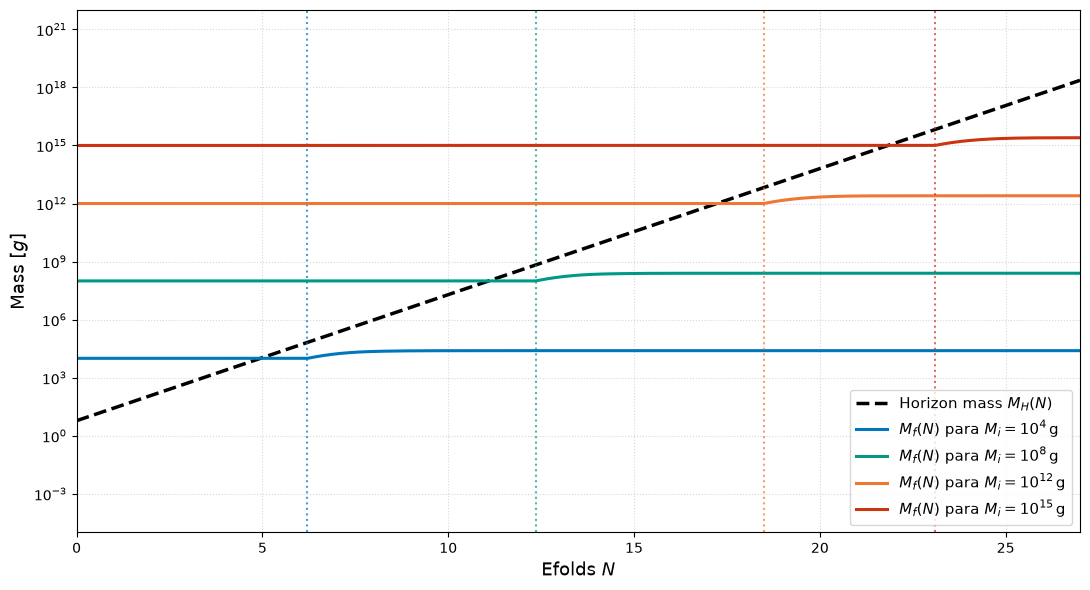

In [9]:
# Ronda 2 (Tarea 6): esta celda usaba una copia PROPIA del modelo de acrecion,
# hardcodeada con el modelo viejo (1-x) y alpha=1/3 -- se habia quedado
# desincronizada del modulo real desde la ronda 1. Ahora llama directamente a
# fn_comp.trayectoria_pbh_vs_horizonte, que comparte la misma fisica
# (regime='wave' por defecto) que el resto del notebook y de functionscorr.py.

def plot_horizonte_vs_pbh():
    N_fin = 27.0
    a_star = 0.0
    L_acc = fn_comp.L_ACC_DEFAULT

    masas_prueba = [1e4, 1e8, 1e12, 1e15]
    colores = ['#0077BB', '#009988', '#EE7733', '#CC3311']

    plt.figure(figsize=(11, 6))

    N_grid, _, M_H_g, _ = fn_comp.trayectoria_pbh_vs_horizonte(masas_prueba[0], N_fin, a_star, L_acc=L_acc)
    plt.plot(N_grid, M_H_g, color='black', linestyle='--', lw=2.5, label=r'Horizon mass $M_H(N)$')

    for idx, M_i in enumerate(masas_prueba):
        _, M_pbh_g, _, N_ini = fn_comp.trayectoria_pbh_vs_horizonte(M_i, N_fin, a_star, L_acc=L_acc)

        plt.plot(N_grid, M_pbh_g, color=colores[idx], lw=2.2,
                 label=rf'$M_f(N)$ para $M_i = 10^{{{int(np.log10(M_i))}}}\,$g')

        plt.axvline(x=float(N_ini), color=colores[idx], linestyle=':', alpha=0.7)

    plt.yscale('log')
    plt.xlabel(r'Efolds $N$', fontsize=13)
    plt.ylabel(r'Mass $[g]$', fontsize=13)
    plt.xlim(0, N_fin)
    plt.ylim(1e-5, 1e22)
    plt.grid(True, which='both', ls=':', alpha=0.5)
    plt.legend(fontsize=11, loc='lower right')
    plt.tight_layout()
    plt.savefig('massvshz.pdf')
    plt.show()

if __name__ == "__main__":
    plot_horizonte_vs_pbh()


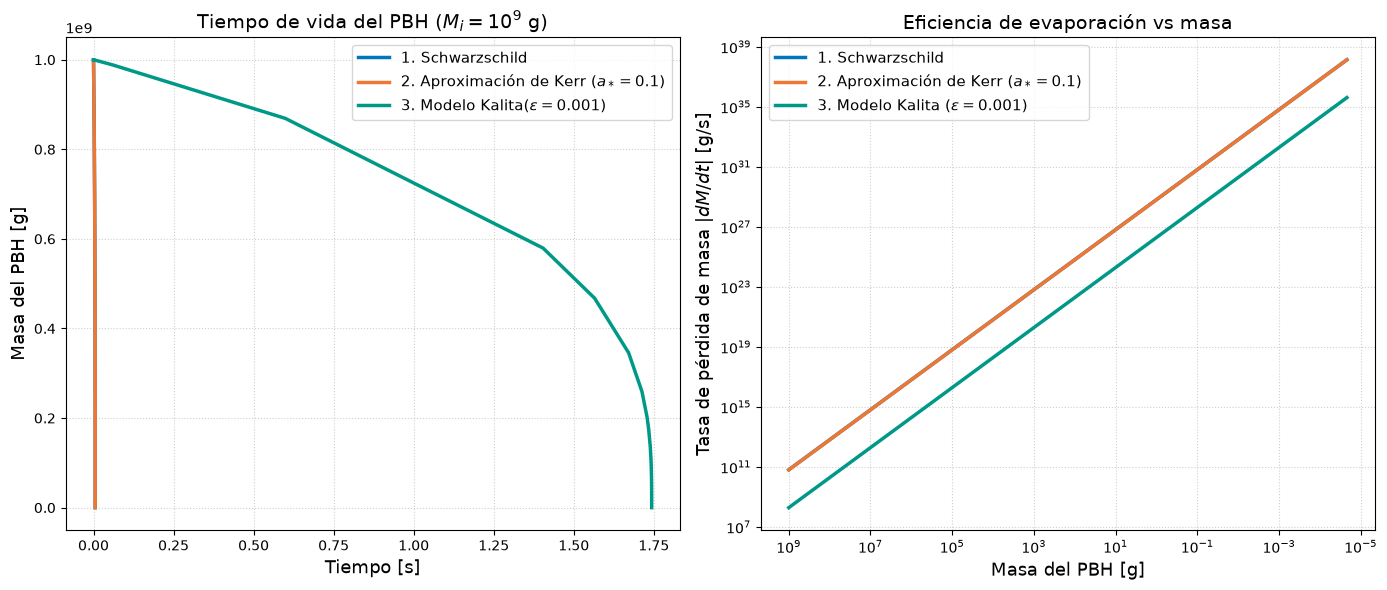

In [10]:
from scipy.integrate import solve_ivp

# Constantes en CGS
M_pl_g = 2.17645e-5
t_pl_s = 5.391247e-44

def comparar_evaporacion(M_i_g=1e9, a_star=0.9):
    # 1. Transformación a unidades de Planck para integración estable
    M_i_pl = M_i_g / M_pl_g
    
    # 2. Factores de los modelos
    # Modelo Kerr Geométrico
    a_safe = np.clip(a_star, 0.0, 0.9999)
    raiz_espin = np.sqrt(1.0 - a_safe**2)
    factor_T = (2.0 * raiz_espin) / (1.0 + raiz_espin)
    factor_A = 0.5 * (1.0 + raiz_espin)
    factor_kerr = (factor_T**4) * factor_A
    
    # Eficiencia de evaporación para el modelo de Kalita
    epsilon = 1e-3

    def rhs_sch(t, M): return [-1.0 / (3.0 * M[0]**2)]
    def rhs_kerr(t, M): return [-(1.0 / 3.0) * factor_kerr / M[0]**2]
    def rhs_usr(t, M): return [-epsilon / M[0]**2]
    
    def evento_fin(t, M): return M[0] - 1.1
    evento_fin.terminal = True
    
    # 4. Integración dinámica calculando un t_max adecuado
    t_max_pl = (M_i_pl**3) / (3.0 * min(epsilon, factor_kerr/3.0, 1.0/3.0)) * 1.5
    
    sol_sch = solve_ivp(rhs_sch, [0, t_max_pl], [M_i_pl], events=evento_fin)
    sol_kerr = solve_ivp(rhs_kerr, [0, t_max_pl], [M_i_pl], events=evento_fin)
    sol_usr = solve_ivp(rhs_usr, [0, t_max_pl], [M_i_pl], events=evento_fin)
    
    # 5. Graficación
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # --- Panel 1: Evolución de la Masa en el tiempo ---
    ax1.plot(sol_sch.t * t_pl_s, sol_sch.y[0] * M_pl_g, label='1. Schwarzschild', lw=2.5, color='#0077BB')
    ax1.plot(sol_kerr.t * t_pl_s, sol_kerr.y[0] * M_pl_g, label=rf'2. Aproximación de Kerr ($a_*={a_star}$)', lw=2.5, color='#EE7733')
    ax1.plot(sol_usr.t * t_pl_s, sol_usr.y[0] * M_pl_g, label=rf'3. Modelo Kalita($\epsilon={epsilon}$)', lw=2.5, color='#009988')
    
    ax1.set_xlabel('Tiempo [s]', fontsize=13)
    ax1.set_ylabel('Masa del PBH [g]', fontsize=13)
    ax1.set_title(f'Tiempo de vida del PBH ($M_i = 10^{{{int(np.log10(M_i_g))}}}$ g)', fontsize=14)
    ax1.grid(True, ls=':', alpha=0.6)
    ax1.legend(fontsize=11)
    
    # --- Panel 2: Tasa de evaporación ---
    M_arr_pl = np.logspace(0, np.log10(M_i_pl), 500)
    M_arr_g = M_arr_pl * M_pl_g
    
    rate_sch = (1.0 / (3.0 * M_arr_pl**2)) * (M_pl_g / t_pl_s)
    rate_kerr = ((1.0 / 3.0) * factor_kerr / M_arr_pl**2) * (M_pl_g / t_pl_s)
    rate_usr = (epsilon / M_arr_pl**2) * (M_pl_g / t_pl_s)
    
    ax2.plot(M_arr_g, rate_sch, label='1. Schwarzschild', lw=2.5, color='#0077BB')
    ax2.plot(M_arr_g, rate_kerr, label=rf'2. Aproximación de Kerr ($a_*={a_star}$)', lw=2.5, color='#EE7733')
    ax2.plot(M_arr_g, rate_usr, label=rf'3. Modelo Kalita ($\epsilon={epsilon}$)', lw=2.5, color='#009988')
    
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.set_xlabel('Masa del PBH [g]', fontsize=13)
    ax2.set_ylabel(r'Tasa de pérdida de masa $|dM/dt|$ [g/s]', fontsize=13)
    ax2.set_title('Eficiencia de evaporación vs masa', fontsize=14)
    ax2.invert_xaxis() 
    ax2.grid(True, which='both', ls=':', alpha=0.6)
    ax2.legend(fontsize=11)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    comparar_evaporacion(M_i_g=1e9, a_star=0.1)

1/3 - Generando espacio de masas...
2/3 - Evaluando modelo Estandar (SBB) base...


3/3 - Calculando acrecion y trazando comparativa...
      -> Procesando L = 25.00


      -> Procesando L = 40.00


      -> Procesando L = 50.27


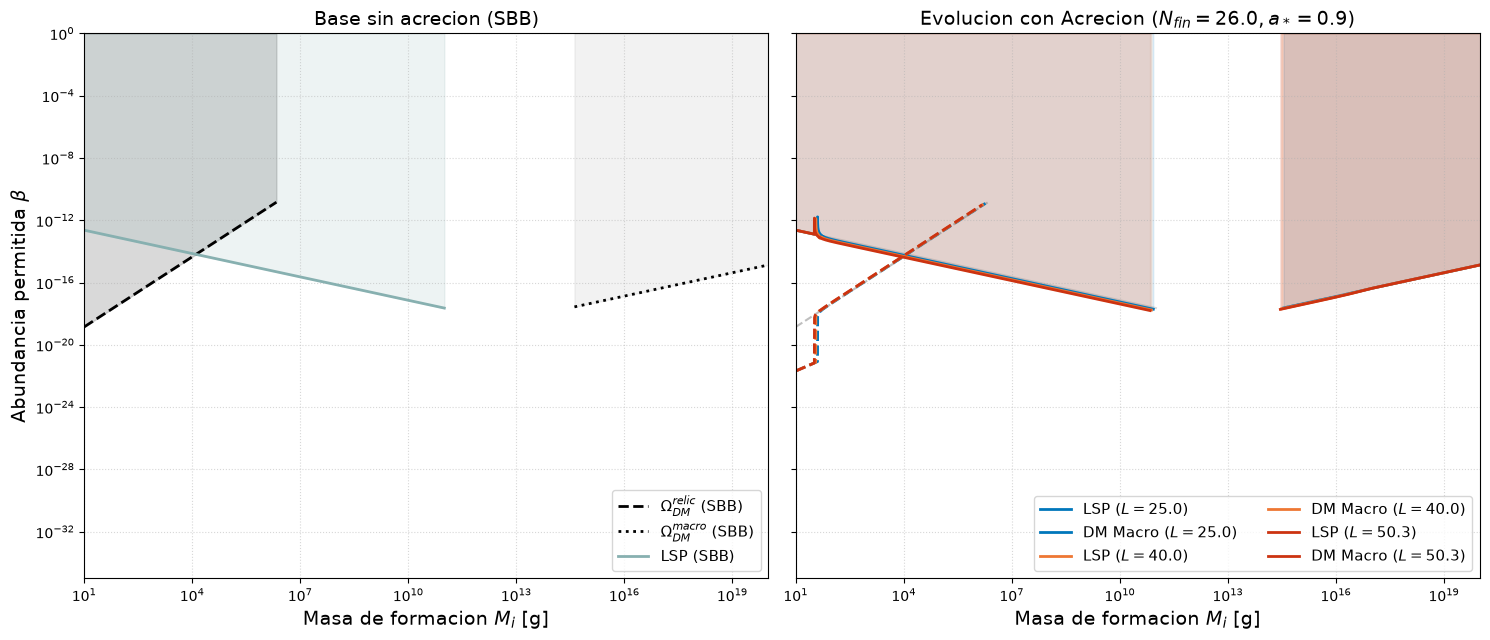

In [11]:
def limpiar_memoria():
    """Limpia las variables globales de PBHBeta para aislar las evaluaciones."""
    fn_comp.constraints.betas_DM_tot = []
    fn_comp.constraints.betas_LSP_tot = []
    fn_comp.constraints.betas_BBN_tot = []
    fn_comp.constraints.betas_SD_tot = []
    fn_comp.constraints.betas_CMB_AN_tot = []
    fn_comp.constraints.betas_GRB_tot = []
    fn_comp.constraints.betas_Reio_tot = []

def clean_beta(b):
    """Enmascara los valores invalidos (ev1) con NaN para matplotlib."""
    return np.where(b == constants.ev1, np.nan, b)

def graficar_eficiencias_dm_lsp():
    print("1/3 - Generando espacio de masas...")
    M_tot = fn_comp.put_M_array(1e-5, 1e22, num_points_low=10000)
    M_tot_jnp = jnp.array(M_tot, dtype=jnp.float64)

    omega = 1.0/3.0
    N_fin = 26.0
    a_star = 0.9

    # Barrido en L (ronda 2): antes lam_lista=[0.5,1.5,2.5] del modelo viejo.
    # factor_espin_acc(0.9)~0.515 da margen hasta L~163 (L*gamma*f_espin<4*pi).
    L_lista = [25.0, 40.0, fn_comp.L_ACC_DEFAULT]
    colores_acc = ['#0077BB', '#EE7733', '#CC3311']

    print("2/3 - Evaluando modelo Estandar (SBB) base...")
    limpiar_memoria()

    fn_comp.Betas_DM(M_tot, omega)
    fn_comp.Betas_LSP(M_tot, omega)

    b_dm_std = np.array(fn_comp.constraints.betas_DM_tot)
    b_lsp_std = np.array(fn_comp.constraints.betas_LSP_tot)

    mask_relic_std = M_tot <= 1e11 * constants.M_pl_g
    mask_macro_std = M_tot > 4.1e14
    b_relic_std = np.where(mask_relic_std, b_dm_std, constants.ev1)
    b_macro_std = np.where(mask_macro_std, b_dm_std, constants.ev1)

    print("3/3 - Calculando acrecion y trazando comparativa...")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5), sharey=True)

    def plot_y_sombrear(ax, y_arr, color, label, linestyle='-', alpha_fill=0.15):
        y_clean = clean_beta(y_arr)
        mask = ~np.isnan(y_clean)
        if np.any(mask):
            line, = ax.plot(M_tot, y_clean, color=color, label=label, linestyle=linestyle, lw=2.0)
            ax.fill_between(M_tot, y_clean, 1.0, where=mask, color=color, alpha=alpha_fill)
            return line
        return None

    ax1.set_title("Base sin acrecion (SBB)", fontsize=14)
    plot_y_sombrear(ax1, b_relic_std, 'black', r'$\Omega_{DM}^{relic}$ (SBB)', linestyle='--')
    plot_y_sombrear(ax1, b_macro_std, 'black', r'$\Omega_{DM}^{macro}$ (SBB)', linestyle=':', alpha_fill=0.05)
    plot_y_sombrear(ax1, b_lsp_std, '#87B0B0', 'LSP (SBB)')

    ax2.set_title(rf"Evolucion con Acrecion ($N_{{fin}} = {N_fin}, a_* = {a_star}$)", fontsize=14)

    ax2.plot(M_tot, clean_beta(b_relic_std), color='grey', linestyle='--', alpha=0.5)
    ax2.plot(M_tot, clean_beta(b_macro_std), color='grey', linestyle=':', alpha=0.5)
    ax2.plot(M_tot, clean_beta(b_lsp_std), color='grey', alpha=0.3)

    for idx, L_acc in enumerate(L_lista):
        print(f"      -> Procesando L = {L_acc:.2f}")

        M_f_tot_jnp, _ = fn_comp.precalcular_acreccion_lote(M_tot_jnp, float(N_fin), float(a_star), L_acc=L_acc)
        M_f_tot = np.maximum.accumulate(np.array(M_f_tot_jnp))

        b_dm_acc = fn_comp.aplicar_corrimiento_acrecion(M_tot, M_f_tot, b_dm_std)
        b_lsp_acc = fn_comp.aplicar_corrimiento_acrecion(M_tot, M_f_tot, b_lsp_std)

        mask_relic_acc = M_f_tot <= 1e11 * constants.M_pl_g
        mask_macro_acc = M_f_tot > 4.1e14
        b_relic_acc = np.where(mask_relic_acc, b_dm_acc, constants.ev1)
        b_macro_acc = np.where(mask_macro_acc, b_dm_acc, constants.ev1)

        color_L = colores_acc[idx]
        plot_y_sombrear(ax2, b_lsp_acc, color_L, rf'LSP ($L={L_acc:.1f}$)', alpha_fill=0.1)
        plot_y_sombrear(ax2, b_macro_acc, color_L, rf'DM Macro ($L={L_acc:.1f}$)', linestyle='-')
        y_relic_clean = clean_beta(b_relic_acc)
        if np.any(~np.isnan(y_relic_clean)):
            ax2.plot(M_tot, y_relic_clean, color=color_L, linestyle='--', lw=2.0)

    for ax in [ax1, ax2]:
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(r'Masa de formacion $M_i$ [g]', fontsize=14)
        ax.set_xlim(1e1, 1e20)
        ax.set_ylim(1e-35, 1e0)
        ax.grid(True, which='both', ls=':', alpha=0.5)

    ax1.set_ylabel(r'Abundancia permitida $\beta$', fontsize=14)

    ax1.legend(loc='lower right', fontsize=11)
    ax2.legend(loc='lower right', fontsize=11, ncol=2)

    plt.tight_layout()
    plt.savefig('dmlsp_eficiencias.pdf')
    plt.show()

if __name__ == "__main__":
    graficar_eficiencias_dm_lsp()


In [12]:
# Ronda 2 (Tarea 6): esta celda calculaba lambda_critico para el modelo
# saturante (1-x) -- ya obsoleto desde la ronda 1 (P0-4 lo reemplazo por
# min(Michel,cap)) y doblemente obsoleto ahora que el default es regime='wave'
# (Unruh 1976, sin (1-x) y sin min()). Se reemplaza por el calculo cerrado del
# regimen actual: mu = 1/(1 - L*gamma/(4*pi)), valido para L*gamma < 4*pi
# (DERIVACION_ACRECION.md S3).

def mu_wave(L, gamma):
    """mu = M_f/M_i en el limite saturado (N_re grande), regime='wave'."""
    producto = L * gamma
    if producto >= 4.0 * np.pi:
        raise ValueError(
            f"L*gamma={producto:.4f} >= 4*pi -- runaway, la solucion cerrada no aplica "
            f"(equivalente a fn_comp.assert_subcritical)."
        )
    return 1.0 / (1.0 - producto / (4.0 * np.pi))


def L_maximo_admisible(gamma):
    """L maximo antes de runaway para un gamma dado."""
    return 4.0 * np.pi / gamma


if __name__ == "__main__":
    print("--- Umbral L*gamma < 4*pi = 12.566 (DERIVACION_ACRECION.md S3) ---\n")

    # CASO 1: los valores por defecto del modulo (L=16*pi, gamma=0.15)
    L0, g0 = fn_comp.L_ACC_DEFAULT, fn_comp.GAMMA_COLAPSO
    print(f"Default del modulo: L={L0:.4f}, gamma={g0}")
    print(f"L*gamma = {L0*g0:.4f}  (limite: {4*np.pi:.4f})")
    print(f"mu = {mu_wave(L0, g0):.4f}\n")

    # CASO 2: gamma_reh=1 (la convencion vieja de PBHBeta/horizon_tracking) -- INADMISIBLE
    print("gamma_reh=1 (convencion PBHBeta, usada en regime='horizon_tracking'):")
    print(f"L*gamma = {L0*1.0:.4f}  (>= {4*np.pi:.4f} -- runaway)")
    try:
        mu_wave(L0, 1.0)
    except ValueError as e:
        print(f"  {e}\n")

    # CASO 3: tabla gamma -> mu, con L=16*pi fijo (reproduce DERIVACION_ACRECION.md S3)
    print("Tabla gamma -> mu (L=16*pi fijo):")
    for gamma in [0.05, 0.10, 0.15, 0.20]:
        print(f"  gamma={gamma:.2f}: L*gamma={L0*gamma:.3f}  mu={mu_wave(L0, gamma):.4f}")


--- Umbral L*gamma < 4*pi = 12.566 (DERIVACION_ACRECION.md S3) ---

Default del modulo: L=50.2655, gamma=0.15
L*gamma = 7.5398  (limite: 12.5664)
mu = 2.5000

gamma_reh=1 (convencion PBHBeta, usada en regime='horizon_tracking'):
L*gamma = 50.2655  (>= 12.5664 -- runaway)
  L*gamma=50.2655 >= 4*pi -- runaway, la solucion cerrada no aplica (equivalente a fn_comp.assert_subcritical).

Tabla gamma -> mu (L=16*pi fijo):
  gamma=0.05: L*gamma=2.513  mu=1.2500
  gamma=0.10: L*gamma=5.027  mu=1.6667
  gamma=0.15: L*gamma=7.540  mu=2.5000
  gamma=0.20: L*gamma=10.053  mu=5.0000
